## 1. Cài đặt

In [2]:
# Cell 1 — setup
import tensorflow as tf
import sys
import numpy as np
import matplotlib.pyplot as plt

## 2. Load MNIST (1 dòng) và quan sát kích thước

In [3]:
# Cell 2 — load dataset MNIST bằng 1 dòng
# MNIST có 70k ảnh 28x28 grayscale: 60k train, 10k test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Thông tin nhanh
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape)
print("y_test  shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test  shape: (10000, 28, 28)
y_test  shape: (10000,)


## Cell 3 — Hiển thị một vài ảnh mẫu để trực quan

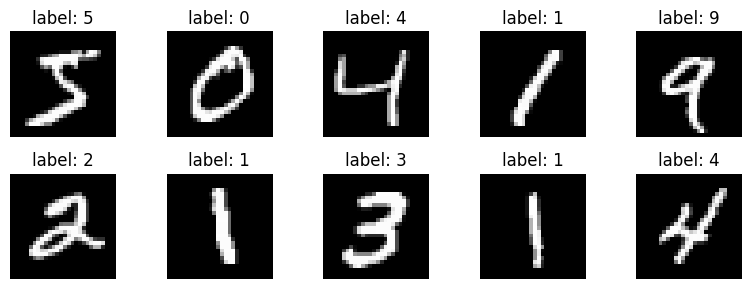

In [4]:
# Cell 3 — visualize vài ảnh
plt.figure(figsize=(8,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()


## Cell 4 — Tiền xử lý: reshape, normalize, one-hot (nếu cần)

In [ ]:
# Cell 4 — preprocessing
# - Thêm channel dimension: (28,28) -> (28,28,1)
# - Normalize pixel về [0,1]
# - Chuyển label sang one-hot nếu dùng categorical_crossentropy

num_classes = 10

# Convert to float32 and scale
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Add channel dimension for Conv2D: NHWC
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# Labels (sử dụng sparse loss để không cần one-hot; nhưng mình cũng show cách one-hot)
y_train_sparse = y_train.copy()   # giữ nguyên (ints) — dùng with sparse_categorical_crossentropy
y_test_sparse  = y_test.copy()

# Nếu muốn one-hot:
y_train_ohe = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_ohe  = tf.keras.utils.to_categorical(y_test, num_classes)

print("After preprocessing:")
print("X_train:", X_train.shape, "dtype:", X_train.dtype)
print("y_train (sparse):", y_train_sparse.shape)
print("y_train (one-hot):", y_train_ohe.shape)


After preprocessing:
X_train: (60000, 28, 28, 1) dtype: float32
y_train (sparse): (60000,)
y_train (one-hot): (60000, 10)


## Cell 5 — Xây dựng model CNN (kiến trúc mẫu) và giải thích các lớp

In [ ]:
# Cell 5 — Xây CNN model (Keras Sequential)
from tensorflow.keras import layers, models

# Mô tả kiến trúc:
# - Conv2D -> ReLU -> MaxPool
# - Conv2D -> ReLU -> MaxPool
# - Flatten -> Dense -> Dropout -> Dense (output)
def make_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(28,28,1), name="input_image"),
        layers.Conv2D(32, kernel_size=3, activation='relu', name="conv1"),
        layers.MaxPooling2D(pool_size=2, name="pool1"),
        layers.Conv2D(64, kernel_size=3, activation='relu', name="conv2"),
        layers.MaxPooling2D(pool_size=2, name="pool2"),
        layers.Flatten(name="flatten"),
        layers.Dense(128, activation='relu', name="fc1"),
        layers.Dropout(0.4, name="dropout"),
        layers.Dense(num_classes, activation='softmax', name="output")
    ])
    return model

model = make_cnn_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 6 — Compile model & giải thích Backprop cơ bản

In [ ]:
# Cell 6 — compile (chọn loss, optimizer, metrics)
# Dùng sparse_categorical_crossentropy để không cần one-hot
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Giải thích backprop ngắn gọn (gồm trong cell):
explanation = """
Backpropagation (lan truyền ngược): sau khi model tính forward (từ input -> output),
ta có loss (mức lỗi). Optimizer (Adam ở đây) dùng gradient của loss theo từng trọng số
(∂Loss/∂w) để cập nhật trọng số theo chiều giảm loss. TensorFlow thực hiện việc tính
gradient tự động (autodiff) và cập nhật theo quy tắc của optimizer.
"""
print(explanation)



Backpropagation (lan truyền ngược): sau khi model tính forward (từ input -> output),
ta có loss (mức lỗi). Optimizer (Adam ở đây) dùng gradient của loss theo từng trọng số
(∂Loss/∂w) để cập nhật trọng số theo chiều giảm loss. TensorFlow thực hiện việc tính
gradient tự động (autodiff) và cập nhật theo quy tắc của optimizer.



## Cell 7 —  Minh họa backprop bằng tay cho 1 batch với GradientTape

In [ ]:
# Cell 7 — minh họa backprop thủ công 1 batch (áp dụng GradientTape)
# Mục đích: cho thấy cách TF tính gradient và update weights (mô tả step-by-step).
# LƯU Ý: đây chỉ là minh họa 1 bước; bình thường ta dùng model.fit.

# Lấy 1 batch nhỏ
batch_size_demo = 32
X_batch = X_train[:batch_size_demo]
y_batch = y_train_sparse[:batch_size_demo]

# Tạo optimizer dùng cho minh họa (cùng Adam)
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

# Một bước huấn luyện thủ công:
with tf.GradientTape() as tape:
    logits = model(X_batch, training=True)   # forward pass
    loss_value = loss_fn(y_batch, logits)

# Tính gradient: list of gradient tensors cho từng biến trainable
grads = tape.gradient(loss_value, model.trainable_variables)

# Ta có thể inspect gradient kích thước / vài giá trị
print("Loss for demo batch:", float(loss_value))
print("Number of trainable vars:", len(model.trainable_variables))
print("Example grad shapes:", [g.shape for g in grads[:6]])

# Cập nhật weights thủ công bằng optimizer
opt.apply_gradients(zip(grads, model.trainable_variables))
print("One manual update applied (demo).")


Loss for demo batch: 2.3167006969451904
Number of trainable vars: 8
Example grad shapes: [TensorShape([3, 3, 1, 32]), TensorShape([32]), TensorShape([3, 3, 32, 64]), TensorShape([64]), TensorShape([1600, 128]), TensorShape([128])]
One manual update applied (demo).


## Cell 8 — Huấn luyện model bằng model.fit

In [ ]:
# Cell 8 — training with model.fit
# Tips: tăng epochs cho kết quả tốt hơn; ở demo đặt epochs nhỏ để nhanh.
epochs = 6
batch_size = 128

history = model.fit(
    X_train, y_train_sparse,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size
)


Epoch 1/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.8130 - loss: 0.6076 - val_accuracy: 0.9830 - val_loss: 0.0631
Epoch 2/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9711 - loss: 0.0951 - val_accuracy: 0.9853 - val_loss: 0.0503
Epoch 3/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9815 - loss: 0.0646 - val_accuracy: 0.9888 - val_loss: 0.0361
Epoch 4/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9845 - loss: 0.0517 - val_accuracy: 0.9900 - val_loss: 0.0349
Epoch 5/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9887 - loss: 0.0368 - val_accuracy: 0.9890 - val_loss: 0.0365
Epoch 6/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.9896 - loss: 0.0321 - val_accuracy: 0.9913 - val_loss: 0.0276


## Cell 9 — Vẽ loss/accuracy qua epochs

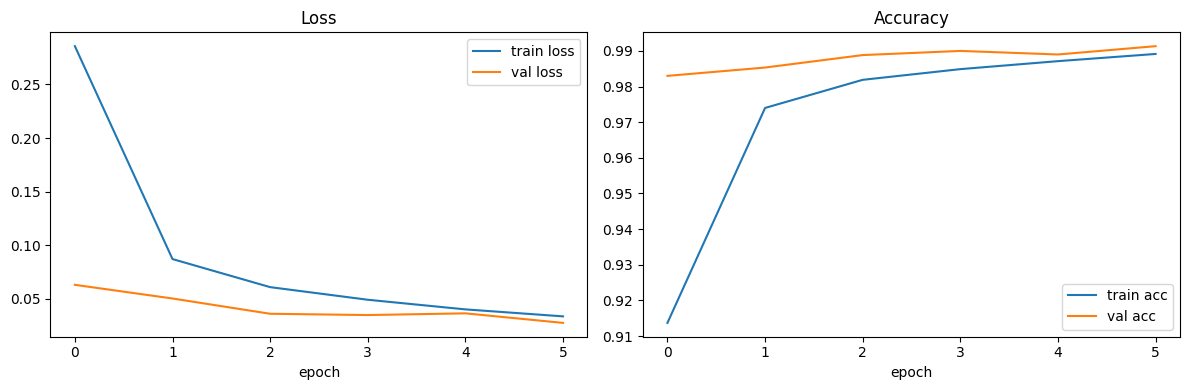

In [ ]:
# Cell 9 — plot training curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.legend()

plt.tight_layout()


## Cell 10 — Evaluate trên tập test

In [ ]:
# Cell 10 — evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_sparse, verbose=2)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")


313/313 - 3s - 10ms/step - accuracy: 0.9909 - loss: 0.0256
Test loss: 0.0256, Test accuracy: 0.9909


## Cell 11 — Dự đoán, hiển thị vài kết quả và ma trận nhầm lẫn

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification report (test):
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



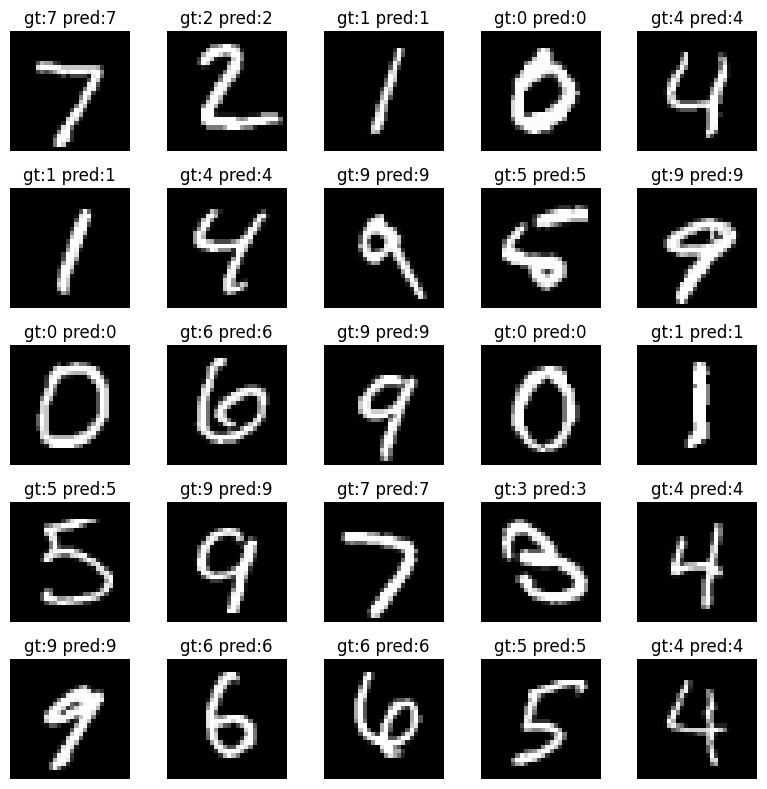

In [ ]:
# Cell 11 — predict some samples and show predictions
preds = model.predict(X_test[:25])
pred_labels = preds.argmax(axis=1)

plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f"gt:{y_test_sparse[i]} pred:{pred_labels[i]}")
    plt.axis('off')
plt.tight_layout()

# Optional: confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test_sparse, model.predict(X_test).argmax(axis=1))
print("Classification report (test):")
print(classification_report(y_test_sparse, model.predict(X_test).argmax(axis=1)))
